In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, 'src')

#from FDEM1D import FDEM1D
from showStitched import showStitchedModels

In [3]:
def FDEM1D(sgm, thk):
    """ 1D FDEM response 
        
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay

    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1

    Freq : frequency of device [Hz]

    coilOrient : array of strings
                  coil orientations: 'H' for horizontal coplanar, 
                  'V' for vertical coplanar, 'P' for perpendicular

    coilSpacing : array
                    separations of the transmitter and receiver coils [m]

    height : float
                height of the device with respect to ground [m]

    Returns
    -------
    Array [OP, IP]

    """  
    # Set geometry
    Freq = 9000
    coilSpacing = [2, 4, 8]
    pcoilSpacing = [2.1, 4.1, 8.1]
    coilOrient = np.array(['H', 'V', 'P'])
    height = 0

    # Source and receivers geometry [x, y, z]
    source    = [0, 0, -height]
    receivers = [coilSpacing, np.zeros(len(coilSpacing)), -height]    
    preceivers = [pcoilSpacing, np.zeros(len(pcoilSpacing)), -height]

    # Depth and resistivity
    res_air = 1e6
    res = np.hstack((res_air, 1/sgm))
    depth = np.hstack((0, np.cumsum(thk)))
    # Empty array to store responses
    OUT = []

    if any(coilOrient == 'H'):

        H_Hs = ep.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect=None, 
                          verb=0)*(2j * np.pi * Freq * mu_0) 
        H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                         ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp() 
        ip = (H_Hs/H_Hp).real.amp() 
        OUT.append([op, ip])

    if any(coilOrient == 'V'):
        V_Hs = ep.dipole(source, receivers, depth, res, Freq, ab =55, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=Freq, 
                         ab=55, verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp() 
        ip = (V_Hs/V_Hp).real.amp() 
        OUT.append([op, ip])

    if any(coilOrient == 'P'):
        # Maybe put 0.1m in receiver offset
        P_Hs = ep.dipole(source, preceivers, depth, res, Freq, ab=46, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = ep.dipole(source, preceivers, depth=[], res=[res_air], freqtime= Freq,
                         ab=66, verb=0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp() 
        ip = (P_Hs/P_Hp).real.amp() 

        OUT.append([op, ip])

    return np.array(OUT).ravel()  

In [4]:
class FDEM1DModelling(pg.frameworks.Modelling):
    
    def __init__(self, nlay=3):
        self.nlay = nlay
        mesh = pg.meshtools.createMesh1DBlock(nlay)
        super().__init__()
        self.setMesh(mesh)
                
    def createStartModel(self, dataVals):
        startThicks = 2
        startSigma = 1/20
        
        # layer thickness properties
        self.setRegionProperties(0, startModel =  startThicks, trans = 'log')
        
        # electrical conductivity properties
        self.setRegionProperties(1, startModel = startSigma, trans = 'log')
        
        return super(FDEM1DModelling, self).createStartModel()
    
    def response(self, par):
        """ Compute response vector for a certain model [mod] 
        par = [thickness_1, thickness_2, ..., thickness_n, sigma_1, sigma_2, ..., sigma_n]
        """
        resp = FDEM1D(np.asarray(par)[self.nlay-1:self.nlay*2-1],   # sigma
                      np.asarray(par)[:self.nlay-1]                  # thickness
                      )
        return resp
    
    def response_mt(self, par, i=0):
        """Multi-threaded forward response."""
        return self.response(par)
    
    def createJacobian(self, par, dx=1e-4):
        """ compute Jacobian for a 1D model """
        resp = self.response(par)
        n_rows = len(resp) # number of data values in data vector
        n_cols = len(par) # number of model parameters
        J = self.jacobian() # we define first this as the jacobian
        J.resize(n_rows, n_cols)
        Jt = np.zeros((n_cols, n_rows))
        for j in range(n_cols):
            mod_plus_dx = par.copy()
            mod_plus_dx[j] += dx
            Jt[j,:] = (self.response(mod_plus_dx) - resp)/dx # J.T in col j
        for i in range(n_rows):
            J[i] = Jt[:,i]
        #print(self.jacobian())
        #print(J)
        #print(Jt)
        
    def drawModel(self, ax, model):
        pg.viewer.mpl.drawModel1D(ax = ax,
                                  model = model,
                                  plot = 'semilogx',
                                  xlabel = 'Electrical conductivity (S/m)',
                                  )
        ax.set_ylabel('Depth in (m)')

# Test

In [264]:
F1D = FDEM1DModelling( nlay=3)

In [265]:
F1D.createJacobian(par = [2, 2, 0.02, 0.02, 0.02])

In [256]:
RM = F1D.regionManager()

In [230]:
RM.mesh()

Mesh: Nodes: 6 Cells: 5 Boundaries: 6

In [231]:
RM.regionCount()

2

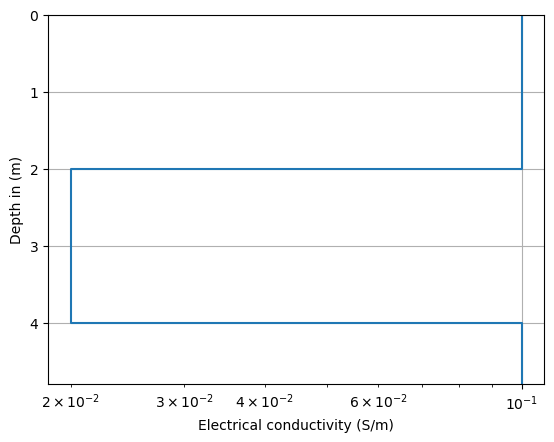

In [232]:
fig, ax = plt.subplots()

F1D.drawModel(ax, model)

# LCI

In [27]:
class LCModelling(pg.frameworks.LCModelling):
    """2D Laterally constrained (LC) modelling.

    2D Laterally constrained (LC) modelling based on BlockMatrices.
    """

    def __init__(self, fop, normalized = True, **kwargs):
        """Parameters: fop class ."""
        self.normalized = normalized
        if self.normalized == True:
            print('Inversion is normalized')
        super().__init__(fop,  **kwargs)

    def initJacobian(self, dataVals, nLay):
        """Initialize Jacobian matrix.

        Parameters
        ----------
        dataVals : ndarray | RMatrix | list
            Data values of size (nSounding x Data per sounding).
            All data per sounding need to be equal in length.
            If they don't fit into a matrix use list of sounding data.
        """

        nPar = 1
        
        nSoundings = len(dataVals)

        self.createParametrization(nSoundings, nLayers = nLay, nPar = nPar)

        if self._jac is not None:
            self._jac.clear()
        else:
            self._jac = pg.matrix.BlockMatrix()

        self.fops1D = []
        nData = 0

        for i in range(nSoundings):
            kwargs = {}
            for key, val in self._fopKwargs.items():
                if hasattr(val, '__iter__'):
                    if len(val) == nSoundings:
                        kwargs[key] = val[i]
                    else:
                        kwargs[key] = [val]
                else:
                    kwargs[key] = val

            f = None
            if issubclass(self._fopTemplate, pg.frameworks.Modelling):
                f = self._fopTemplate(**kwargs)
            else:
                f = type(self._fopTemplate)(self.verbose, **kwargs)

            f.setMultiThreadJacobian(self._parPerSounding)

            self._fops1D.append(f)

            nID = self._jac.addMatrix(f.jacobian())
            #print(nID)
            self._jac.addMatrixEntry(nID, nData, self._parPerSounding * i)
            #print(self._jac)
            nData += len(dataVals[i])

        self._jac.recalcMatrixSize()
        print("Jacobian size:", self._jac.rows(), self._jac.cols(), nData)
        self.setJacobian(self._jac)
        
    def createJacobian(self, par):
        """Create Jacobian matrix by creating individual Jacobians."""
        mods = np.asarray(par).reshape(self._nSoundings, self._parPerSounding)

        for i in range(self._nSoundings):
            self._fops1D[i].createJacobian(mods[i])
            
        #print('Jacobian shape:',np.shape(self._jac))
        #return self._jac
    
    def response(self, par):
        """Cut together forward responses of all soundings."""
        
        mods = np.asarray(par).reshape(self._nSoundings, self._parPerSounding)

        resp = pg.Vector(0)
        for i in range(self._nSoundings):
            r = self._fops1D[i].response(mods[i])
            resp = pg.cat(resp, r)
        return resp
    
    def constraint_matrix(self, dataVals, nLay=None):
        """ Create constraint matrix

        Parameters
        ----------
            dataVals : list of 1D pyGIMLi data vectors (nSounding x Data per sounding) [list]
            nLayers : number of layers (for blocky inversion) [int]
        """

        nSoundings = len(dataVals) # number of soundings
        
        boundaries_thk = (nLay - 1) * (nSoundings - 1) # inner mesh boundaries for thicknesses
        boundaries_sig = nLay * (nSoundings - 1) # inner mesh boundaries for conductivities

        CM = np.zeros((boundaries_thk + boundaries_sig, (nLay *2 - 1) * nSoundings))
        h = -np.eye(1, nLay * 2) + np.eye(1, nLay * 2, k = (nLay * 2 - 1))

        for i in range(boundaries_thk + boundaries_sig):
            CM[i, i:h.shape[1]+i] = h

        #print('Size of constraint matrix:', np.shape(CM))

        self.CM = pg.utils.toSparseMatrix(CM) # convert to sparse pg matrix

        return self.CM
    
    def createWeight(self, dataVals, cWeight_1, cWeight_2, nLay=None):
        """ Create constraint weights (cWeights)
            Blocky model : vertical constraint weights for both model parameter regions

        Parameters
        ----------
            dataVals : list of 1D pyGIMLi data vectors [list]
            cWeight_1 : vertical constraint weight (smooth model) or thickness constraint weight
                        (blocky model) [float]
            cWeight_2 : horizontal constraint weight (smooth model) or resistivity constraint weight
                        (blocky model) [float]
            nLay : number of layers (for blocky inversion) [int]
        """
        nSoundings = len(dataVals) # number of soundings
        
        """ constraint weights for blocky model """
        cWeight_thk = cWeight_1
        cWeight_sig = cWeight_2

        boundaries_thk = (nLay - 1) * (nSoundings - 1)
        boundaries_sig = nLay * (nSoundings - 1)

        cWeight_thk = pg.Vector(boundaries_thk, cWeight_thk)

        cWeight_sig = pg.Vector(boundaries_sig, cWeight_sig)
        
        if self.normalized == True:
            self.cWeight = pg.cat(cWeight_thk, cWeight_sig) / self.norm * (boundaries_thk + boundaries_sig)
        else:
            self.cWeight = pg.cat(cWeight_thk, cWeight_sig)
        print('Constraint cWeight:', self.cWeight)
        #return self.cWeight

    def createConstraints(self):
        """ create weighted constraint matrix """
        self._CW = pg.matrix.LMultRMatrix(self.CM, self.cWeight, verbose = True)
        self.setConstraints(self._CW)
        print('CW: ', self._CW)
        
    def normalization(self, dataVals, cWeight_1, cWeight_2, phiM_norm =[0, 0.5, 0.5, 1], nLay=None):
        """ Create normalization factor
        
        Parameters
        ----------
        dataVals : list of 1D pygimli data vectors
        cWeight_1 : thickness constraint weight
        cWeight_2 : electrical conductivity constraint weight
        phiM_norm : model objective function calculated by multiplying inversion 
                    starting model with constraint matrix for 4 cases
        nLay : number of layers
        """
        
        cWeight_thk = cWeight_1
        cWeight_sig = cWeight_2
        
        cWeight_ratio_thk = cWeight_thk / (cWeight_sig + cWeight_thk)
        cWeight_ratio_sig = cWeight_sig / (cWeight_sig + cWeight_thk)
        
        if cWeight_thk == cWeight_sig and cWeight_thk == 0:
            print('cWeights are zero')
            slope = phiM_norm[0]
            self.norm = 0
            raise ValueError('At least one cWeight should be non-zero')
            
        elif cWeight_thk == cWeight_sig and cWeight_thk != 0:
            print('cWeights are equal')
            slope = phiM_norm[3]
            self.norm = slope * cWeight_thk
            
        elif cWeight_sig == 0 and cWeight_thk != 0:
            print('only cWeight for thickness')
            slope = phiM_norm[2]
            self.norm = slope * cWeight_thk
            
        elif cWeight_thk == 0 and cWeight_sig != 0:
            print('only cWeight for resistivity')
            slope = phiM_norm[1]
            self.norm = slope * cWeight_sig
            
        elif cWeight_thk < cWeight_sig:
            print('cWeight for resistivity is dominant')
            slope_sig = phiM_norm[1]
            slope_thk = phiM_norm[2]
            self.norm = slope_sig * cWeight_sig + slope_thk * cWeight_thk * cWeight_ratio_thk
            
        else:
            print('cWeight for thickness is dominant')
            slope_sig = phiM_norm[1]
            slope_thk = phiM_norm[2]
            self.norm = slope_thk * cWeight_thk + slope_sig * cWeight_sig * cWeight_ratio_sig   

    def drawModel(self, ax, model, **kwargs):
        """Draw models as stitched 1D model section."""
        mods = np.asarray(model).reshape(self._nSoundings,
                                         self._parPerSounding)
        pg.viewer.mpl.showStitchedModels(mods, ax=ax, useMesh=True,
                                         x=self.soundingPos,
                                         **kwargs)

In [73]:
## Create a test model

pos = 10
nLayers = 3

x =  np.linspace(0,pos,pos, endpoint=False)
sigm_1 = 100/1000
sigm_2 = 50/1000
sigm_3 = 100/1000
thk_1 = x/9 + 1 #np.sin(np.pi/2*x/3) + 2
thk_2 = 4 - thk_1 # 1/9*x + 1.5

models = np.zeros((pos, nLayers*2-1))
models[:,0] = thk_1
models[:,1] = thk_2
models[:,2] = sigm_1
models[:,3] = sigm_2
models[:,4] = sigm_3

nSoundings = pos

## Create test data

data_t = []

for p in range(pos):
    data_t.append(FDEM1D(models[p,2:], models[p,:2]))

<AxesSubplot:title={'center':'True Model'}>

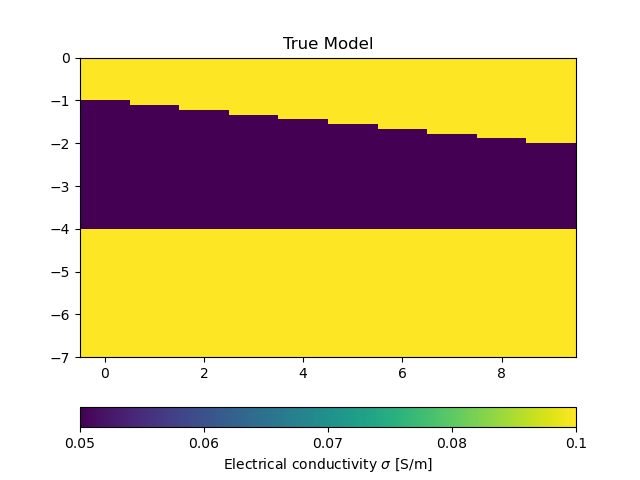

In [74]:
inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]'}

showStitchedModels(models, zMax=7, title = 'True Model', **inputs)

In [110]:
LC = LCModelling(FDEM1DModelling)

Inversion is normalized


In [111]:
LC.initJacobian(dataVals=data_t, nLay=3)
LC.createJacobian(models)
LC.constraint_matrix(data_t, nLay=3)
LC.normalization(data_t, cWeight_1=0, cWeight_2=1, nLay=3)
LC.createWeight(data_t, cWeight_1=0, cWeight_2=1, nLay=3)
LC.createConstraints()


Jacobian size: 162 45 180
only cWeight for resistivity
Constraint cWeight: 45 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0]
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f980b4bcf90>


# Test

In [39]:
#LC.regionManager().fillConstraintWeights()

In [40]:
LC.cWeight.size

45

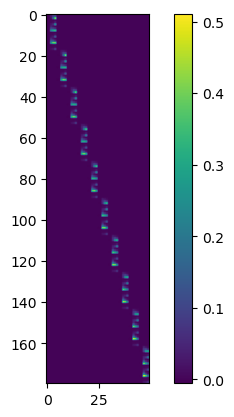

In [41]:
fig, ax = plt.subplots()
c = ax.imshow(J)
fig.colorbar(c)

(<AxesSubplot:>, None)

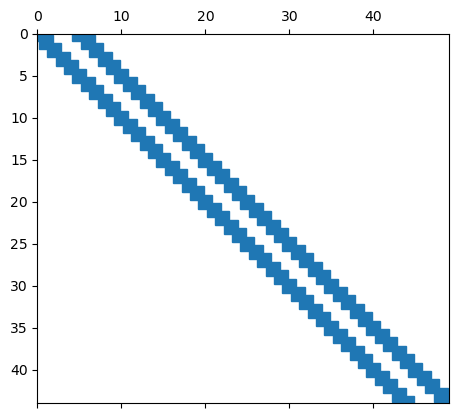

In [239]:
pg.show(CM)


(<AxesSubplot:>, None)

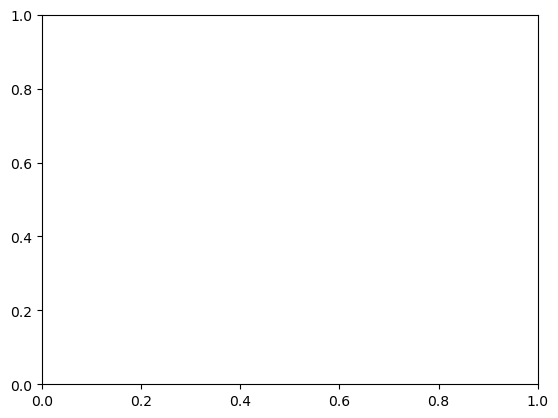

In [240]:
pg.show(CW)

In [241]:
RM = LC.regionManager()

In [242]:
cm = RM.paraDomain().cellMarkers()
cm

50 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

In [243]:
RM.regionIdxs()

2 [1, 2]

(<AxesSubplot:>, <matplotlib.colorbar.Colorbar at 0x7fc0bc5df640>)

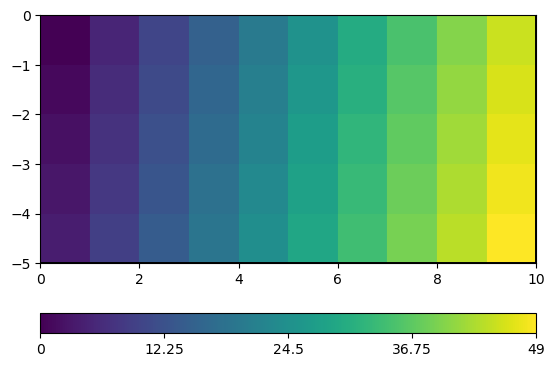

In [244]:
pg.show(m,cm)

# Inversion

In [112]:
# Initial model
m0 = models.copy()
m0[:,:2] = 2
m0[:,2:] = 50/1000

In [113]:
# Define inversion
#LC.region(1).setConstraintType(1)
#LC.region(2).setConstraintType(1)

inv = pg.Inversion(LC)
data_true = np.array(data_t).ravel()
relativeError = np.ones_like(data_true)*1e-3


27/02/24 - 15:51:53 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


In [114]:
models_est = inv.run(data_true, relativeError, startModel=m0.ravel(), verbose=True)

27/02/24 - 15:51:54 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.05 0.05 0.05 2.   2.   0.05 0.05 0.05 2.   2.   0.05 0.05
 0.05 2.   2.   0.05 0.05 0.05 2.   2.   0.05 0.05 0.05 2.   2.   0.05
 0.05 0.05 2.   2.   0.05 0.05 0.05 2.   2.   0.05 0.05 0.05 2.   2.
 0.05 0.05 0.05 2.   2.   0.05 0.05 0.05]
27/02/24 - 15:51:54 - pyGIMLi - INFO - Starting inversion.
27/02/24 - 15:51:54 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


min/max(dweight) = 10759.4/9.21339e+06
fop: <__main__.LCModelling object at 0x7f980baf1720>
Data transformation: <pgcore._pygimli_.RTrans object at 0x7f9809ed9280>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x7f980baf1c70>
min/max (data): 1.1e-04/0.09
min/max (error): 0.1%/0.1%
min/max (start model): 0.05/2
--------------------------------------------------------------------------------
min/max(dweight) = 10759.4/9.21339e+06
 found valid constraints matrix. omit rebuild
constraint matrix of size(nBounds x nModel) 45 x 50
calculating jacobian matrix (forced=1)...... 0.245 s
min data = 0.000108538 max data = 0.0929417 (180)
min error = 0.001 max error = 0.001 (180)
min response = 4.55966e-05 max response = 0.0557529 (180)
calc without reference model
0: rms/rrms(data, response) = 0.0117418/47.6379%
0: chi^2(data, response, error, log) = 226937
0: Phi = 4.08487e+07 + 0 * 20 = 4.08487e+07
Iter: 0
solve CGLSCDWWtrans with lambda = 20
1: LS newModel: min = 0.0197423; max = 2

<AxesSubplot:title={'center':'Estimated Model LCI'}>

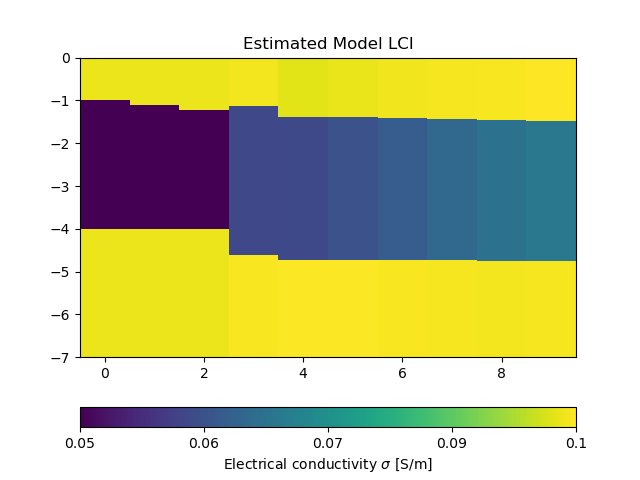

In [115]:
inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]'}

showStitchedModels(np.array(models_est).reshape(np.shape(models)), zMax=7, 
                  title = 'Estimated Model LCI', **inputs)
